In [ ]:
!pip install shap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy as sp
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, roc_curve
from datetime import timedelta

from sklearn.calibration import calibration_curve
import shap

from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configuração de Estilo
plt.style.use('dark_background')
shap.initjs()

# Configuração visual de alto padrão
plt.style.use('dark_background')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

In [2]:
print("1. Carregando a Base Corporativa...")
# Atualizado com o seu novo caminho
df = pd.read_parquet('../src/ifrs9_framework/data/raw/synthetic_credit_data.parquet')
print(f"Total de Contratos Analisados: {len(df)}")

1. Carregando a Base Corporativa...
Total de Contratos Analisados: 374486


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374486 entries, 0 to 374485
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   cliente_id         374486 non-null  int64         
 1   idade              374486 non-null  float64       
 2   renda              374486 non-null  float64       
 3   uf                 374486 non-null  object        
 4   zona_risco_flag    374486 non-null  int64         
 5   bureau_score       374486 non-null  float64       
 6   obito_flag         374486 non-null  int64         
 7   codigo_contrato    374486 non-null  object        
 8   tipo_produto       374486 non-null  object        
 9   data_contratacao   374486 non-null  datetime64[ns]
 10  prazo_meses        374486 non-null  int64         
 11  data_vencimento    374486 non-null  datetime64[ns]
 12  limite_credito     374486 non-null  float64       
 13  valor_financiado   374486 non-null  float64 

In [4]:
df.head(10)

,cliente_id,idade,renda,uf,zona_risco_flag,bureau_score,obito_flag,codigo_contrato,tipo_produto,data_contratacao,prazo_meses,data_vencimento,limite_credito,valor_financiado,selic_contratacao,default_flag,churn_flag,data_evento
0,1,58.953998,2302.091770,MA,1,458.690273,0,4f2c04d0,Consignado SIAPE,2021-11-06,79,2028-05-03,0.0,10711.228896,5.081772,0,0,2028-05-03
1,1,58.953998,2302.091770,MA,1,458.690273,0,de9929d6,Consignado SIAPE,2022-06-12,93,2030-01-31,0.0,7319.579877,13.149033,0,0,2030-01-31
2,1,58.953998,2302.091770,MA,1,458.690273,0,ca147a05,Consignado INSS,2023-01-17,90,2030-06-09,0.0,5377.525954,12.454835,0,1,2024-09-08
3,2,50.064300,5547.355046,RJ,0,588.041646,0,f833304b,Consignado INSS,2023-01-26,95,2030-11-15,0.0,8629.994977,5.521695,0,0,2030-11-15
4,3,61.067640,3537.639538,MA,0,671.794326,0,5262dd9b,Consignado INSS,2022-06-09,84,2029-05-03,0.0,30517.265019,12.181277,0,1,2022-10-07
5,3,61.067640,3537.639538,MA,0,671.794326,0,8c7c4909,Consignado INSS,2025-03-15,62,2030-04-18,0.0,30626.834589,2.461180,0,0,2030-04-18
6,4,73.322418,1936.541607,PA,0,499.260789,0,006e2f40,Consignado INSS,2022-09-27,90,2030-02-17,0.0,2648.221510,12.320086,0,0,2030-02-17
7,5,48.721853,1374.534343,MG,0,627.609039,0,72d36764,Consignado INSS,2025-04-15,100,2033-07-02,0.0,4361.169620,8.088767,0,0,2033-07-02
8,5,48.721853,1374.534343,MG,0,627.609039,0,f0aa9f6e,Consignado INSS,2023-02-21,88,2030-05-15,0.0,1960.078429,11.189314,0,0,2030-05-15
9,5,48.721853,1374.534343,MG,0,627.609039,0,0c34dbab,Consignado SIAPE,2022-12-24,60,2027-11-28,0.0,9121.812559,4.365357,0,1,2024-11-13


In [5]:
df.describe()

,cliente_id,idade,renda,zona_risco_flag,bureau_score,obito_flag,data_contratacao,prazo_meses,data_vencimento,limite_credito,valor_financiado,selic_contratacao,default_flag,churn_flag,data_evento
count,374486.000000,374486.000000,374486.000000,374486.000000,374486.000000,374486.000000,374486,374486.000000,374486,374486.000000,3.744860e+05,374486.000000,374486.000000,374486.000000,374486
mean,75040.214462,52.059085,5741.515079,0.096588,649.752355,0.005725,2023-12-24 00:14:37.413841920,64.575503,2029-04-13 06:36:22.460225024,947.998267,1.855994e+04,7.873256,0.017451,0.118888,2028-09-04 15:16:35.136800
min,1.000000,18.000000,1320.002535,0.000000,80.381745,0.000000,2021-07-09 00:00:00,12.000000,2022-07-05 00:00:00,0.000000,0.000000e+00,2.000011,0.000000,0.000000,2021-08-08 00:00:00
25%,37542.000000,42.575706,1689.457596,0.000000,562.335784,0.000000,2022-10-01 00:00:00,37.000000,2027-08-03 00:00:00,0.000000,3.211661e+03,4.931845,0.000000,0.000000,2026-04-24 00:00:00
50%,74973.000000,52.025327,2398.804577,0.000000,649.608654,0.000000,2023-12-24 00:00:00,73.000000,2029-06-16 00:00:00,0.000000,7.174744e+03,7.872491,0.000000,0.000000,2028-10-28 00:00:00
75%,112533.000000,61.475516,4372.005401,0.000000,737.933196,0.000000,2025-03-17 00:00:00,84.000000,2031-03-26 00:00:00,0.000000,1.463303e+04,10.812149,0.000000,0.000000,2030-11-25 00:00:00
max,150000.000000,95.000000,150000.000000,1.000000,1000.000000,1.000000,2026-06-11 00:00:00,120.000000,2036-04-04 00:00:00,50000.000000,2.258524e+06,13.749984,1.000000,1.000000,2036-04-04 00:00:00
std,43316.784439,13.897513,13709.685244,0.295397,129.753058,0.075448,NaN,25.344232,NaN,4309.266938,5.842378e+04,3.392498,0.130943,0.323657,NaN


In [6]:
# 1. Calcular a média
media = np.mean(df['renda'].values)
# 2. Calcular o desvio padrão 
desvio_padrao = np.std(df['renda'].values)

In [7]:
# 3. Calcular o Coeficiente de Variação
cv = desvio_padrao / media
cv

2.3878134517157994

In [8]:
# Lista de colunas numéricas contínuas (removi as flags binárias, explicarei o porquê)
colunas_continuas = ['idade', 'renda', 'bureau_score', 'prazo_meses', 'limite_credito', 'valor_financiado', 'selic_contratacao']

print("--- DIAGNÓSTICO DE VOLATILIDADE (COEFICIENTE DE VARIAÇÃO) ---\n")

for col in colunas_continuas:
    # Usamos 'col' para acessar especificamente a coluna da iteração atual
    cv = df[col].std() / df[col].mean()
    
    # Adicionando uma lógica de semáforo visual para facilitar a leitura
    alerta = "🔴 ALTO" if cv > 1.0 else "🟡 MÉDIO" if cv > 0.3 else "🟢 BAIXO"
    
    print(f"{col.ljust(20)} | CV: {cv:.4f} ({cv * 100:>6.2f}%) | Risco de Outliers: {alerta}")

--- DIAGNÓSTICO DE VOLATILIDADE (COEFICIENTE DE VARIAÇÃO) ---

idade                | CV: 0.2670 ( 26.70%) | Risco de Outliers: 🟢 BAIXO
renda                | CV: 2.3878 (238.78%) | Risco de Outliers: 🔴 ALTO
bureau_score         | CV: 0.1997 ( 19.97%) | Risco de Outliers: 🟢 BAIXO
prazo_meses          | CV: 0.3925 ( 39.25%) | Risco de Outliers: 🟡 MÉDIO
limite_credito       | CV: 4.5456 (454.56%) | Risco de Outliers: 🔴 ALTO
valor_financiado     | CV: 3.1478 (314.78%) | Risco de Outliers: 🔴 ALTO
selic_contratacao    | CV: 0.4309 ( 43.09%) | Risco de Outliers: 🟡 MÉDIO


In [9]:
print("\n2. Engenharia do Espaço Vetorial (Pre-processing)...")
# Selecionamos features críticas para o cluster e transformamos strings em matriz binária
features_numericas = ['idade', 'renda', 'bureau_score', 'limite_credito', 'valor_financiado', 'selic_contratacao']
df_features = pd.get_dummies(df[features_numericas + ['tipo_produto']], columns=['tipo_produto'])


2. Engenharia do Espaço Vetorial (Pre-processing)...


In [10]:
# Padronização (Crucial para o PCA: média 0, variância 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [11]:
print("\n3. Redução de Dimensionalidade (PCA)...")
# Reduzindo dezenas de colunas para apenas 2 eixos principais (X e Y vetoriais)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]
print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")


3. Redução de Dimensionalidade (PCA)...
Variância explicada pelos 2 componentes: 36.00%


In [12]:
print("\n4. Aplicando K-Means (Buscando 4 nichos de comportamento)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['cluster_id'] = kmeans.fit_predict(X_scaled)


4. Aplicando K-Means (Buscando 4 nichos de comportamento)...


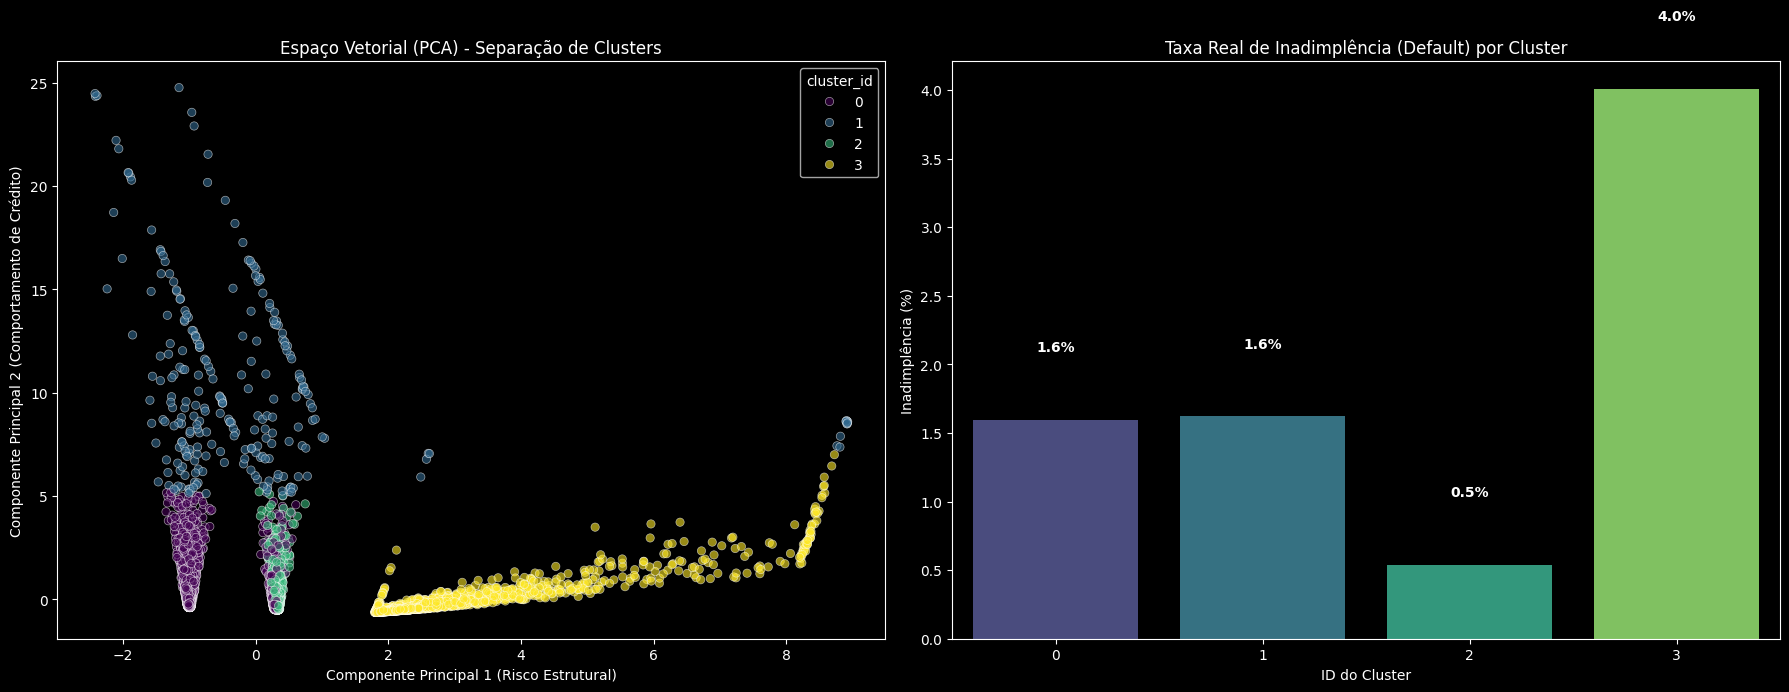


5. Perfil de Risco (A Resposta do Estudo):


,tipo_produto,bureau_score,renda,taxa_default
cluster_id,,,,
0,Consignado INSS,649.547503,4443.436650,1.6%
1,Consignado INSS,649.850360,109703.254847,1.6%
2,Consignado SIAPE,649.941349,4512.999832,0.5%
3,Cartão de Crédito,650.377362,5032.387056,4.0%


In [13]:
# ================= VIZUALIZAÇÃO =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: A separação matemática dos clusters
sns.scatterplot(
    data=df.sample(20000), # Amostra para não travar a renderização gráfica
    x='pca_1', y='pca_2', 
    hue='cluster_id', 
    palette='viridis', 
    alpha=0.6, 
    ax=ax1
)
ax1.set_title("Espaço Vetorial (PCA) - Separação de Clusters")
ax1.set_xlabel("Componente Principal 1 (Risco Estrutural)")
ax1.set_ylabel("Componente Principal 2 (Comportamento de Crédito)")

# Gráfico 2: Prova de Fogo (Inadimplência por Cluster)
taxa_default_cluster = df.groupby('cluster_id')['default_flag'].mean() * 100
sns.barplot(x=taxa_default_cluster.index, y=taxa_default_cluster.values, palette='viridis', ax=ax2)
ax2.set_title("Taxa Real de Inadimplência (Default) por Cluster")
ax2.set_ylabel("Inadimplência (%)")
ax2.set_xlabel("ID do Cluster")

# Adicionando o rótulo de dados no gráfico de barras
for i, v in enumerate(taxa_default_cluster.values):
    ax2.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n5. Perfil de Risco (A Resposta do Estudo):")
# Descobrindo o que cada cluster representa no mundo real
perfil = df.groupby('cluster_id').agg({
    'tipo_produto': lambda x: x.value_counts().index[0], # Produto dominante no cluster
    'bureau_score': 'mean',
    'renda': 'mean',
    'default_flag': 'mean'
}).rename(columns={'default_flag': 'taxa_default'})
perfil['taxa_default'] = (perfil['taxa_default'] * 100).round(1).astype(str) + '%'

display(perfil)

--- INICIANDO ENGENHARIA DE FEATURES (YEO-JOHNSON) ---
Transformação concluída para: renda -> renda_yj
Transformação concluída para: limite_credito -> limite_credito_yj
Transformação concluída para: valor_financiado -> valor_financiado_yj

--- NOVO DIAGNÓSTICO DE VOLATILIDADE (PÓS-CURA) ---


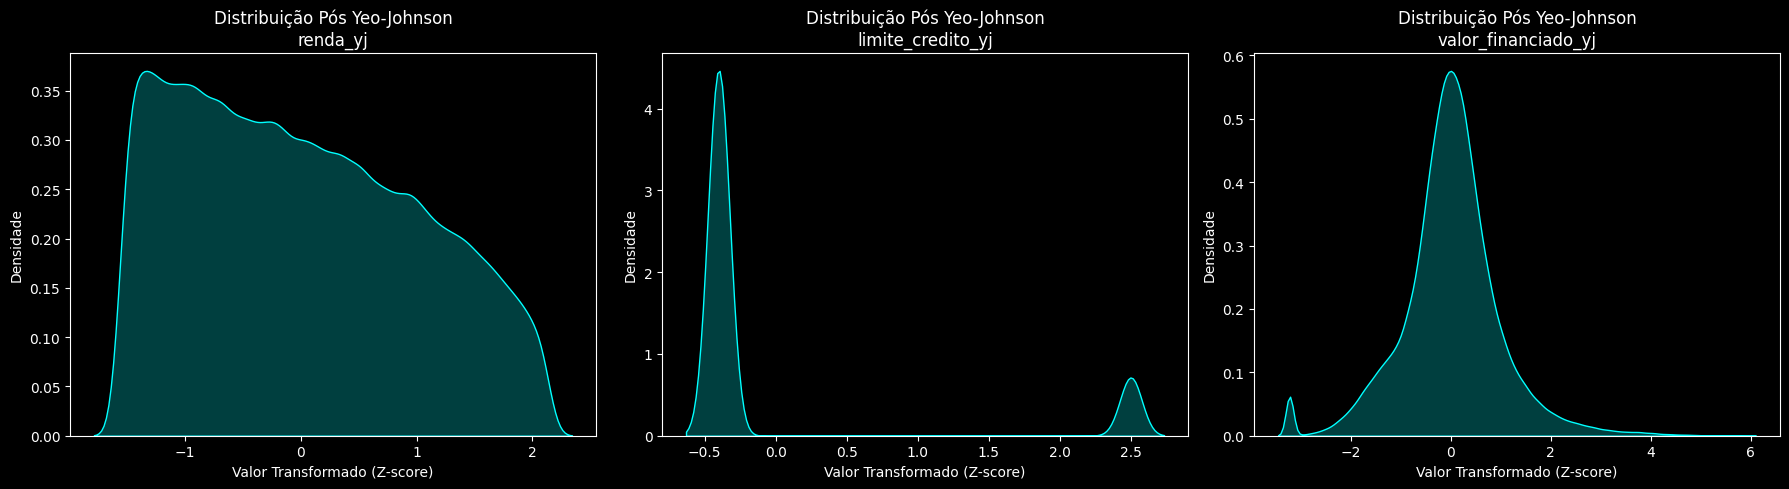

Verifique os gráficos: A assimetria severa desapareceu. Onde havia caudas longas, agora temos sinos estabilizados.


In [14]:
print("--- INICIANDO ENGENHARIA DE FEATURES (YEO-JOHNSON) ---")

# Vamos focar nas colunas que gritaram ALTO risco no seu diagnóstico
colunas_criticas = ['renda', 'limite_credito', 'valor_financiado']

# Inicializamos o transformador de potência (Yeo-Johnson é o padrão)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Criamos cópias para não destruir os dados originais no dataframe
for col in colunas_criticas:
    nome_nova_col = f"{col}_yj"
    # O fit_transform exige um formato 2D, por isso os dois colchetes
    df[nome_nova_col] = pt.fit_transform(df[[col]])
    print(f"Transformação concluída para: {col} -> {nome_nova_col}")

print("\n--- NOVO DIAGNÓSTICO DE VOLATILIDADE (PÓS-CURA) ---")

colunas_curadas = [f"{c}_yj" for c in colunas_criticas]

fig, axes = plt.subplots(1, len(colunas_criticas), figsize=(18, 5))

for i, col in enumerate(colunas_curadas):
    # Calculando o novo CV (Nota: como standardizamos, a média é ~0, então olhamos a distribuição visual)
    # Plotando o antes e o depois
    
    sns.kdeplot(df[col], ax=axes[i], fill=True, color='cyan')
    axes[i].set_title(f"Distribuição Pós Yeo-Johnson\n{col}")
    axes[i].set_xlabel("Valor Transformado (Z-score)")
    axes[i].set_ylabel("Densidade")

plt.tight_layout()
plt.show()

print("Verifique os gráficos: A assimetria severa desapareceu. Onde havia caudas longas, agora temos sinos estabilizados.")

In [ ]:
# print("--- INICIANDO RADAR DE ANOMALIAS (MAHALANOBIS) ---")

# # Selecionamos nossas features purificadas e outras contínuas cruciais
# features_radar = ['idade', 'bureau_score', 'renda_yj', 'limite_credito_yj', 'valor_financiado_yj']
# df_radar = df[features_radar].copy()

# # A Matemática Vetorizada de Mahalanobis
# def calculate_mahalanobis(y=None, data=None, cov=None):
#     y_mu = y - np.mean(data, axis=0)
#     if not cov:
#         cov = np.cov(data.values.T)
#     inv_covmat = sp.linalg.inv(cov)
#     left_term = np.dot(y_mu, inv_covmat)
#     mahal = np.dot(left_term, y_mu.T)
#     return mahal.diagonal()

# # Calculando a distância (D^2) para os ~400 mil contratos
# df['distancia_mahalanobis'] = calculate_mahalanobis(y=df_radar, data=df_radar)

# # Como D^2 segue uma distribuição Qui-Quadrado (Chi-Square), podemos achar o limiar exato
# # Vamos marcar como ANOMALIA (Fraude/Outlier extremo) os 0.5% dados mais distantes (p-value < 0.005)
# graus_liberdade = len(features_radar)
# limiar_anomalia = chi2.ppf((1 - 0.005), graus_liberdade)

# df['anomalia_multivariada'] = (df['distancia_mahalanobis'] > limiar_anomalia).astype(int)

# anomalias_encontradas = df['anomalia_multivariada'].sum()
# print(f"\nLimiar Matemático (Chi-Square): {limiar_anomalia:.2f}")
# print(f"Total de Anomalias Multivariadas Detectadas: {anomalias_encontradas} ({anomalias_encontradas/len(df)*100:.2f}%)")

# # ================= VIZUALIZAÇÃO =================
# fig, ax = plt.subplots(figsize=(12, 6))

# # Plotando os clientes normais (com transparência para formar a nuvem)
# normais = df[df['anomalia_multivariada'] == 0]
# ax.scatter(normais['idade'], normais['renda_yj'], color='cyan', alpha=0.1, label='Base Saudável', s=5)

# # Plotando as anomalias detectadas em vermelho vivo
# anomalias = df[df['anomalia_multivariada'] == 1]
# ax.scatter(anomalias['idade'], anomalias['renda_yj'], color='#ff3333', edgecolors='white', label='Anomalias (Outliers)', s=25)

# ax.set_title("Detecção de Fraude/Outliers no Espaço Multidimensional\n(Idade vs Renda Normalizada)")
# ax.set_xlabel("Idade do Cliente")
# ax.set_ylabel("Renda (Transformada Yeo-Johnson)")
# ax.legend()

# plt.tight_layout()
# plt.show()

# # Validando o Risco das Anomalias
# print("\nTaxa de Default - Base Saudável vs Anomalias:")
# display(df.groupby('anomalia_multivariada')[['default_flag', 'churn_flag', 'valor_financiado']].mean())

--- INICIANDO RADAR DE ANOMALIAS (MAHALANOBIS OTIMIZADO) ---

Limiar Matemático (Chi-Square): 16.75
Total de Anomalias Detectadas: 7474 (2.00%)


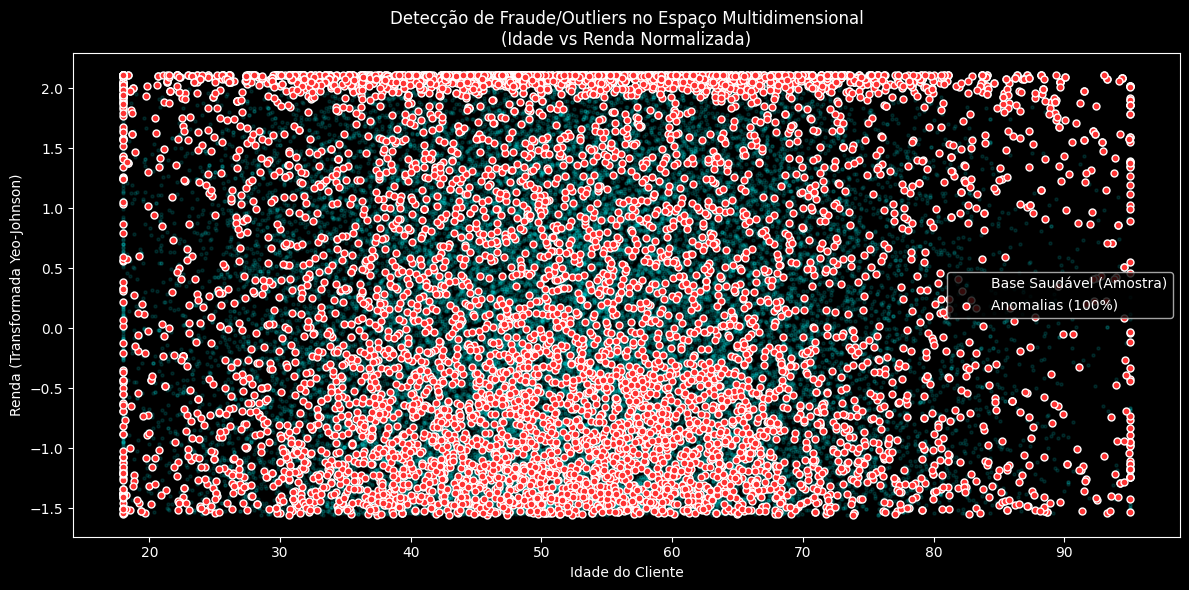


Taxa de Default - Base Saudável vs Anomalias:


,default_flag,churn_flag,valor_financiado
anomalia_multivariada,,,
0,0.017196,0.119754,15397.907230
1,0.029971,0.076398,173831.944604


In [15]:
print("--- INICIANDO RADAR DE ANOMALIAS (MAHALANOBIS OTIMIZADO) ---")

features_radar = ['idade', 'bureau_score', 'renda_yj', 'limite_credito_yj', 'valor_financiado_yj']
df_radar = df[features_radar].copy()

# OTIMIZAÇÃO DE MEMÓRIA (Evitando a explosão da matriz N x N)
def calculate_mahalanobis_optimized(y=None, data=None, cov=None):
    y_mu = y - np.mean(data, axis=0)
    if not cov:
        cov = np.cov(data.values.T)
    inv_covmat = sp.linalg.inv(cov)
    left_term = np.dot(y_mu, inv_covmat)
    
    # A correção mágica: multiplicação element-wise e soma pelo eixo 1.
    # Extrai diretamente a diagonal da matriz teórica, gastando zero RAM extra.
    mahal = np.sum(left_term * y_mu, axis=1)
    return mahal

# Calculando a distância instantaneamente
df['distancia_mahalanobis'] = calculate_mahalanobis_optimized(y=df_radar, data=df_radar)

graus_liberdade = len(features_radar)
limiar_anomalia = chi2.ppf((1 - 0.005), graus_liberdade)
df['anomalia_multivariada'] = (df['distancia_mahalanobis'] > limiar_anomalia).astype(int)

anomalias_encontradas = df['anomalia_multivariada'].sum()
print(f"\nLimiar Matemático (Chi-Square): {limiar_anomalia:.2f}")
print(f"Total de Anomalias Detectadas: {anomalias_encontradas} ({anomalias_encontradas/len(df)*100:.2f}%)")

# ================= VIZUALIZAÇÃO INTELIGENTE =================
fig, ax = plt.subplots(figsize=(12, 6))

normais = df[df['anomalia_multivariada'] == 0]
anomalias = df[df['anomalia_multivariada'] == 1]

# Amostragem assimétrica: Plotamos só 30k normais, mas 100% das fraudes.
amostra_normais = normais.sample(n=min(30000, len(normais)), random_state=42)

ax.scatter(amostra_normais['idade'], amostra_normais['renda_yj'], color='cyan', alpha=0.1, label='Base Saudável (Amostra)', s=5)
ax.scatter(anomalias['idade'], anomalias['renda_yj'], color='#ff3333', edgecolors='white', label='Anomalias (100%)', s=25)

ax.set_title("Detecção de Fraude/Outliers no Espaço Multidimensional\n(Idade vs Renda Normalizada)")
ax.set_xlabel("Idade do Cliente")
ax.set_ylabel("Renda (Transformada Yeo-Johnson)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nTaxa de Default - Base Saudável vs Anomalias:")
display(df.groupby('anomalia_multivariada')[['default_flag', 'churn_flag', 'valor_financiado']].mean())

In [16]:
print("--- 1. PREPARAÇÃO DA MÁQUINA DO TEMPO (OUT-OF-TIME) ---")

# Ordenamos a base estritamente pela data de contratação
df = df.sort_values('data_contratacao').reset_index(drop=True)

# O ponto de corte será os 80% mais antigos para treino, e os 20% mais recentes para teste
corte_idx = int(len(df) * 0.8)
train_df = df.iloc[:corte_idx]
test_df = df.iloc[corte_idx:]

data_corte = train_df['data_contratacao'].max().strftime('%Y-%m-%d')
print(f"Data de Corte OOT: {data_corte}")
print(f"Treino (Passado): {len(train_df)} contratos | Teste (Futuro): {len(test_df)} contratos")

# Definindo quem é variável explicativa (X) e quem é o alvo (y)
features = [
    'idade', 'bureau_score', 'selic_contratacao', 'prazo_meses',
    'renda_yj', 'limite_credito_yj', 'valor_financiado_yj', # Variáveis Curadas
    'tipo_produto', 'zona_risco_flag', 'anomalia_multivariada' # Categóricas e Radar
]
cat_features = ['tipo_produto'] # O CatBoost engole texto puro sem precisar de One-Hot Encoding!

X_train, y_train = train_df[features], train_df['default_flag']
X_test, y_test = test_df[features], test_df['default_flag']

--- 1. PREPARAÇÃO DA MÁQUINA DO TEMPO (OUT-OF-TIME) ---
Data de Corte OOT: 2025-06-15
Treino (Passado): 299588 contratos | Teste (Futuro): 74898 contratos


In [17]:
print("\n--- 2. INICIANDO TREINAMENTO: CATBOOST CLASSIFIER ---")
# O Motor de Inteligência Artificial
model = CatBoostClassifier(
    iterations=500,               # Número de árvores
    learning_rate=0.05,           # Velocidade de aprendizado (baixo evita overfitting)
    depth=6,                      # Profundidade da árvore (6 é ideal para bases grandes)
    auto_class_weights='Balanced',# A Mágica para bases de 2% de default: reequilibra os pesos
    cat_features=cat_features,
    eval_metric='AUC',            # Mede a capacidade de separação
    random_seed=42,
    verbose=100                   # Imprime o log a cada 100 árvores
)

# Treinando e validando simultaneamente (Early Stopping para se o modelo parar de aprender)
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)


--- 2. INICIANDO TREINAMENTO: CATBOOST CLASSIFIER ---
0:	test: 0.7828012	best: 0.7828012 (0)	total: 393ms	remaining: 3m 16s
100:	test: 0.8046330	best: 0.8046330 (100)	total: 23.6s	remaining: 1m 33s
200:	test: 0.8057161	best: 0.8057634 (196)	total: 37.8s	remaining: 56.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8057633654
bestIteration = 196

Shrink model to first 197 iterations.


CatBoostClassifier(auto_class_weights='Balanced', cat_features=['tipo_produto'], depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)


--- 3. AVALIAÇÃO DE PERFORMANCE (MÉTRICAS DE BANCO) ---
Gini Score (Poder de Separação): 61.15%
KS Statistic (Maior Distância entre Bons e Maus): 52.88%


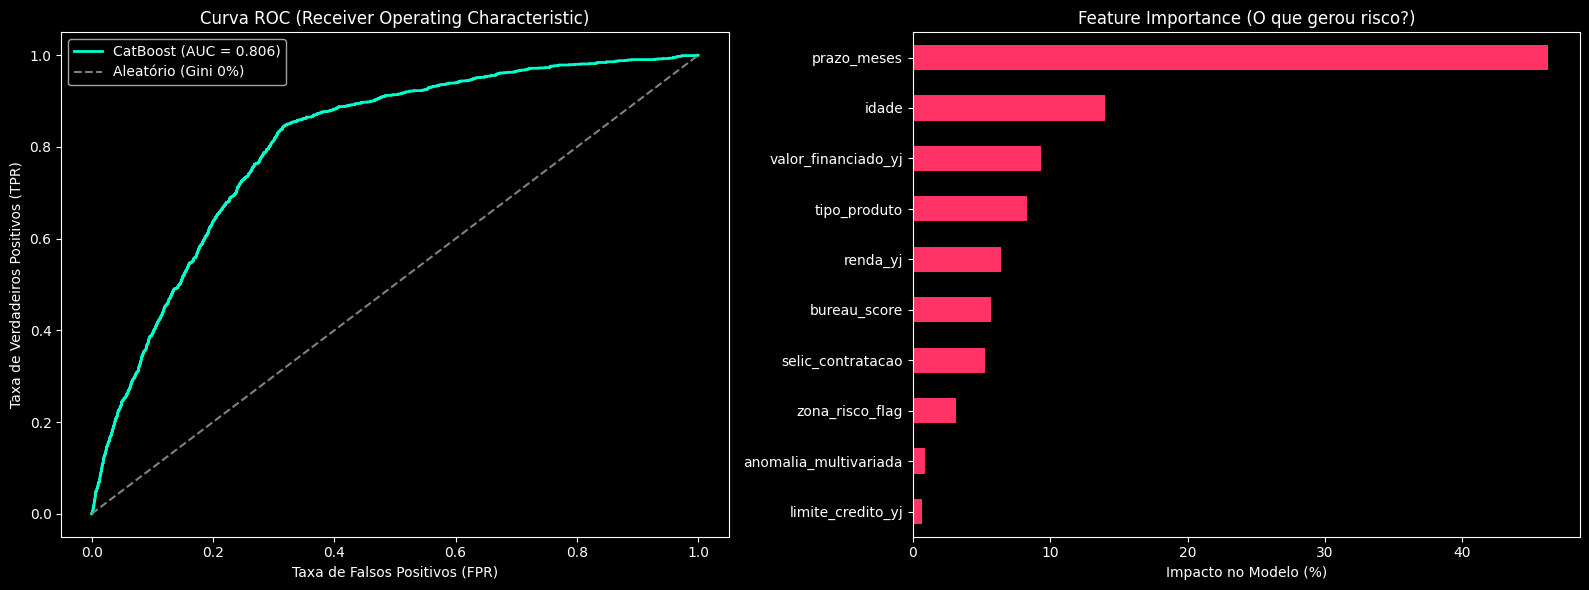

In [18]:
print("\n--- 3. AVALIAÇÃO DE PERFORMANCE (MÉTRICAS DE BANCO) ---")

# Prevendo a probabilidade matemática [0.0 a 1.0] de quebrar no futuro
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Cálculo do ROC-AUC e Gini
auc_roc = roc_auc_score(y_test, y_pred_proba)
gini = (2 * auc_roc) - 1

# Cálculo da Estatística KS (Kolmogorov-Smirnov) - A métrica mais amada por diretores de risco
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks_statistic = np.max(tpr - fpr)
ks_idx = np.argmax(tpr - fpr)

print(f"Gini Score (Poder de Separação): {gini * 100:.2f}%")
print(f"KS Statistic (Maior Distância entre Bons e Maus): {ks_statistic * 100:.2f}%")

# ================= VIZUALIZAÇÃO =================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.style.use('dark_background')

# Gráfico 1: Curva ROC (AUC)
ax1.plot(fpr, tpr, color='#00ffcc', lw=2, label=f'CatBoost (AUC = {auc_roc:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório (Gini 0%)')
ax1.set_title("Curva ROC (Receiver Operating Characteristic)")
ax1.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax1.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax1.legend()

# Gráfico 2: Importância das Features (O que o modelo mais olhou?)
importances = model.get_feature_importance()
feat_importances = pd.Series(importances, index=features).sort_values(ascending=True)
feat_importances.plot(kind='barh', color='#ff3366', ax=ax2)
ax2.set_title("Feature Importance (O que gerou risco?)")
ax2.set_xlabel("Impacto no Modelo (%)")

plt.tight_layout()
plt.show()

--- 1. AUDITORIA DE CALIBRAÇÃO (TABELA DE DECIS) ---

Tabela de Risco por Decil (1 = Pior Risco | 10 = Melhor Risco):


,decil,Volume_Contratos,PD_Prevista_Media,Taxa_Default_Real,Calotes_Absolutos,Captura_Calotes_%
0,1,7490,77.66%,6.49%,486,38.3%
1,2,7490,70.06%,3.95%,296,61.6%
2,3,7490,65.26%,3.06%,229,79.7%
3,4,7489,39.61%,1.39%,104,87.9%
4,5,7490,24.81%,0.57%,43,91.3%
5,6,7490,20.22%,0.45%,34,93.9%
6,7,7489,17.43%,0.41%,31,96.4%
7,8,7490,15.06%,0.28%,21,98.0%
8,9,7490,13.05%,0.17%,13,99.1%
9,10,7490,11.05%,0.16%,12,100.0%


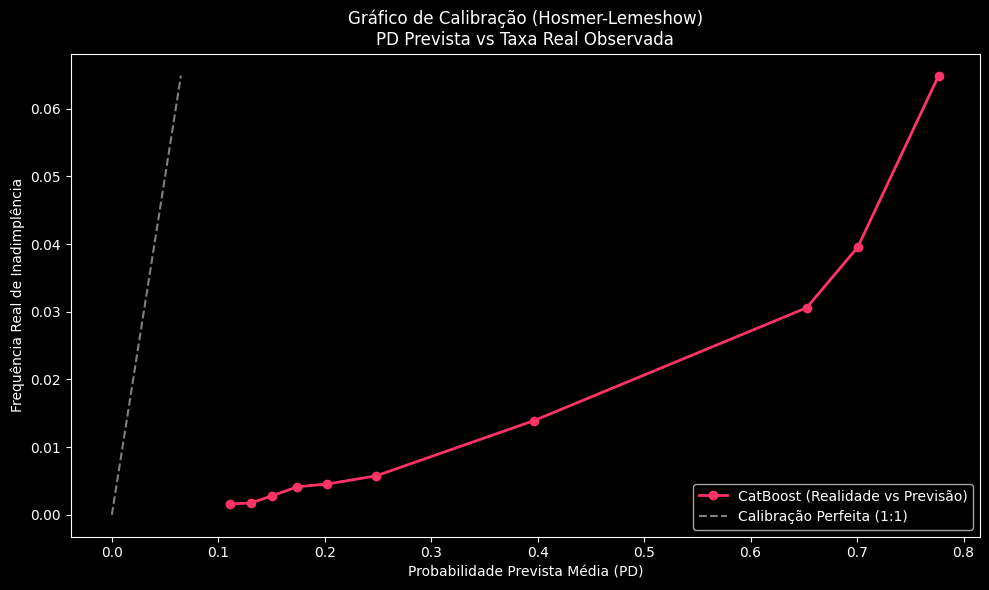

In [19]:
# Configuração de Estilo
plt.style.use('dark_background')
shap.initjs()

print("--- 1. AUDITORIA DE CALIBRAÇÃO (TABELA DE DECIS) ---")

# Criando um DataFrame de resultados para a base de Teste
resultados_teste = pd.DataFrame({
    'default_real': y_test,
    'pd_prevista': y_pred_proba
})

# Ordenando do Maior Risco para o Menor Risco e criando 10 Decis
resultados_teste['rank'] = resultados_teste['pd_prevista'].rank(method='first', ascending=False)
resultados_teste['decil'] = pd.qcut(resultados_teste['rank'], 10, labels=np.arange(1, 11))

# Agrupando a Tabela Gerencial
tabela_decis = resultados_teste.groupby('decil').agg(
    Volume_Contratos=('pd_prevista', 'count'),
    PD_Prevista_Media=('pd_prevista', 'mean'),
    Taxa_Default_Real=('default_real', 'mean'),
    Calotes_Absolutos=('default_real', 'sum')
).reset_index()

# Calculando a captura acumulada (Lift)
tabela_decis['Captura_Calotes_%'] = (tabela_decis['Calotes_Absolutos'] / tabela_decis['Calotes_Absolutos'].sum()).cumsum() * 100

print("\nTabela de Risco por Decil (1 = Pior Risco | 10 = Melhor Risco):")
display(tabela_decis.style.format({
    'PD_Prevista_Media': '{:.2%}', 
    'Taxa_Default_Real': '{:.2%}',
    'Captura_Calotes_%': '{:.1f}%'
}))

# ================= VIZUALIZAÇÃO DE CALIBRAÇÃO =================
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de Calibração (Hosmer-Lemeshow Visual)
# Extraímos os pontos exatos usando o scikit-learn
prob_real, prob_prevista = calibration_curve(resultados_teste['default_real'], resultados_teste['pd_prevista'], n_bins=10, strategy='quantile')

ax.plot(prob_prevista, prob_real, marker='o', color='#ff3366', linewidth=2, label='CatBoost (Realidade vs Previsão)')
ax.plot([0, prob_real.max()], [0, prob_real.max()], linestyle='--', color='gray', label='Calibração Perfeita (1:1)')

ax.set_title("Gráfico de Calibração (Hosmer-Lemeshow)\nPD Prevista vs Taxa Real Observada")
ax.set_xlabel("Probabilidade Prevista Média (PD)")
ax.set_ylabel("Frequência Real de Inadimplência")
ax.legend()
plt.tight_layout()
plt.show()


--- 2. CAIXA PRETA: DECOMPOSIÇÃO SHAP (TEORIA DOS JOGOS) ---
Analisando o impacto das variáveis para um cliente isolado...


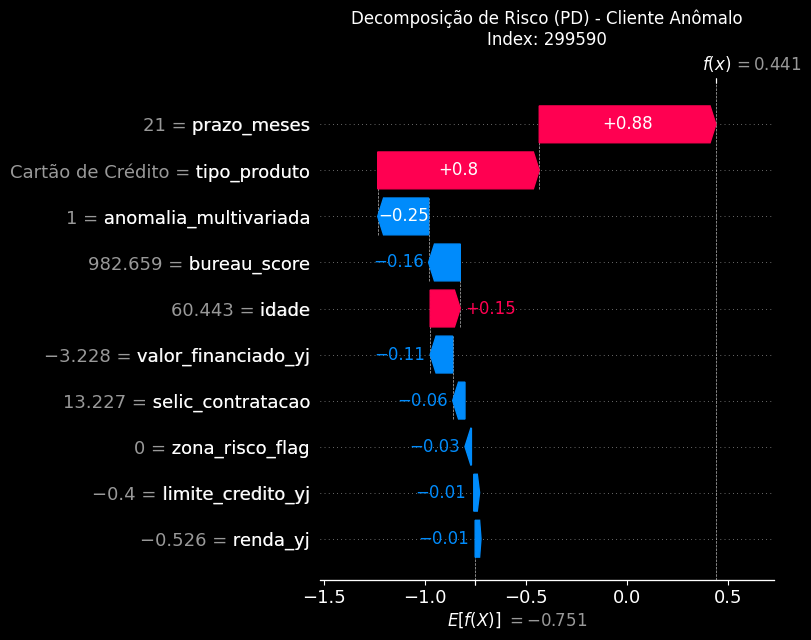

In [20]:
print("\n--- 2. CAIXA PRETA: DECOMPOSIÇÃO SHAP (TEORIA DOS JOGOS) ---")
print("Analisando o impacto das variáveis para um cliente isolado...")

# Inicializando o explicador SHAP no nosso CatBoost
explainer = shap.TreeExplainer(model)

# Vamos pegar um cliente de Teste que nós sabemos que o Radar de Anomalia marcou como "1"
indice_anomalia = X_test[X_test['anomalia_multivariada'] == 1].index[0]
cliente_alvo = X_test.loc[[indice_anomalia]]

# Calculando os valores SHAP apenas para este cliente
shap_values = explainer(cliente_alvo)

# Plotando o Waterfall (Cascata) de Risco
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title(f"Decomposição de Risco (PD) - Cliente Anômalo\nIndex: {indice_anomalia}")
plt.tight_layout()
plt.show()

In [21]:
print("--- 1. CALIBRAÇÃO ISOTÔNICA (AJUSTE DE PROBABILIDADE REAL) ---")

# Para calibrar corretamente, precisamos das probabilidades previstas na base de TREINO
y_train_proba = model.predict_proba(X_train)[:, 1]

# Treinando o Calibrador Isotônico (Ele aprende os "degraus" da distorção)
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(y_train_proba, y_train)

# Aplicando a cura nas probabilidades do nosso modelo de Teste
pd_calibrada = iso_reg.transform(y_pred_proba)

# Injetando os resultados no DataFrame de Teste para o Backtesting
test_df_results = test_df.copy()
test_df_results['pd_bruta_catboost'] = y_pred_proba
test_df_results['pd_calibrada_real'] = pd_calibrada

print(f"PD Média Bruta (CatBoost): {y_pred_proba.mean():.4f}")
print(f"PD Média Calibrada (Isotônica): {pd_calibrada.mean():.4f} | Taxa Real de Default: {y_test.mean():.4f}")
print("✓ Calibração Concluída: O modelo agora entende que a carteira tem ~2% de risco, e não 50%!")

--- 1. CALIBRAÇÃO ISOTÔNICA (AJUSTE DE PROBABILIDADE REAL) ---
PD Média Bruta (CatBoost): 0.3542
PD Média Calibrada (Isotônica): 0.0175 | Taxa Real de Default: 0.0169
✓ Calibração Concluída: O modelo agora entende que a carteira tem ~2% de risco, e não 50%!


In [22]:
print("\n--- 2. MATRIZ DE CONFUSÃO E PODER DE CLASSIFICAÇÃO ---")

# Definindo a Política de Crédito: Vamos usar a nota de corte (cut-off) que achamos no KS (~4%)
# Quem tiver PD Calibrada > 4% será NEGADO (Classificado como 1 - Mau Pagador)
nota_de_corte = 0.04
previsoes_finais = (pd_calibrada > nota_de_corte).astype(int)

cm = confusion_matrix(y_test, previsoes_finais)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plotando a Matriz de Confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax1, 
            xticklabels=['Aprovado (0)', 'Negado (1)'], 
            yticklabels=['Bom Pagador (0)', 'Inadimplente (1)'])
ax1.set_title(f"Mesa de Crédito - Matriz de Confusão (Cut-off: {nota_de_corte*100}%)")
ax1.set_ylabel("Mundo Real")
ax1.set_xlabel("Decisão do Modelo")

# Imprimindo as métricas
print("\nRelatório de Classificação da Mesa de Crédito:")
print(classification_report(y_test, previsoes_finais, target_names=['Bons Pagadores', 'Inadimplentes']))


--- 2. MATRIZ DE CONFUSÃO E PODER DE CLASSIFICAÇÃO ---

Relatório de Classificação da Mesa de Crédito:
                precision    recall  f1-score   support

Bons Pagadores       0.99      0.82      0.90     73629
 Inadimplentes       0.05      0.58      0.10      1269

      accuracy                           0.82     74898
     macro avg       0.52      0.70      0.50     74898
  weighted avg       0.98      0.82      0.88     74898




--- 3. BACKTESTING TEMPORAL (VINTAGE ANALYSIS) ---


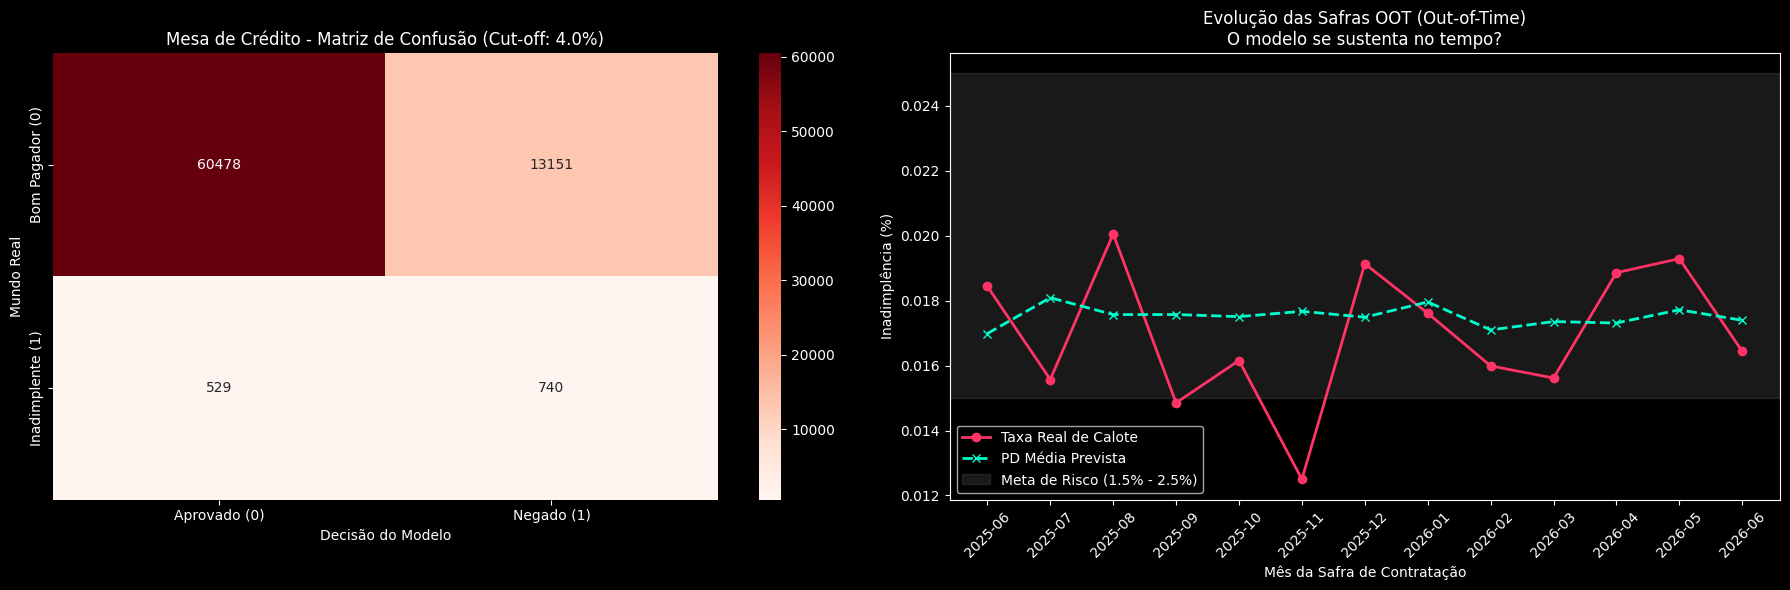

In [23]:
print("\n--- 3. BACKTESTING TEMPORAL (VINTAGE ANALYSIS) ---")

# Vamos agrupar os contratos pelo MÊS de contratação
test_df_results['mes_safra'] = test_df_results['data_contratacao'].dt.to_period('M')

# Calculando a PD e a Taxa Real para cada Safra (Mês)
backtest = test_df_results.groupby('mes_safra').agg(
    Volume=('default_flag', 'count'),
    Taxa_Real=('default_flag', 'mean'),
    PD_Calibrada=('pd_calibrada_real', 'mean')
).reset_index()

# Convertendo de volta para string para o gráfico
backtest['mes_safra'] = backtest['mes_safra'].astype(str)

# Gráfico de Backtesting
ax2.plot(backtest['mes_safra'], backtest['Taxa_Real'], marker='o', color='#ff3366', linewidth=2, label='Taxa Real de Calote')
ax2.plot(backtest['mes_safra'], backtest['PD_Calibrada'], marker='x', linestyle='--', color='#00ffcc', linewidth=2, label='PD Média Prevista')

# Sombreando a zona de "Risco Controlado" (Nossa meta inicial de ~2%)
ax2.axhspan(0.015, 0.025, color='gray', alpha=0.2, label='Meta de Risco (1.5% - 2.5%)')

ax2.set_title("Evolução das Safras OOT (Out-of-Time)\nO modelo se sustenta no tempo?")
ax2.set_xlabel("Mês da Safra de Contratação")
ax2.set_ylabel("Inadimplência (%)")
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

In [24]:
# from datetime import timedelta
print("--- 1. ENGENHARIA MACROECONÔMICA (INFLAÇÃO E DESEMPREGO) ---")

# Vamos garantir que a nossa base tem a coluna de mês para o cruzamento macro
df['mes_safra'] = df['data_contratacao'].dt.to_period('M')

# Gerando um histórico macroeconômico simulado dos últimos 5 anos (60 meses)
# Usando processos estocásticos simples (Passeios Aleatórios) para simular o Brasil
np.random.seed(42)
meses_unicos = df['mes_safra'].sort_values().unique()

# IPCA mensal (Inflação): Flutua entre -0.2% e 1.5%
ipca_mensal = np.random.normal(0.4, 0.3, len(meses_unicos)).clip(-0.2, 1.5)
# Desemprego: Começa em 8%, sofre choques e flutua
desemprego = np.cumsum(np.random.normal(0, 0.5, len(meses_unicos))) + 8.0
desemprego = desemprego.clip(4.0, 15.0)

tabela_macro = pd.DataFrame({
    'mes_safra': meses_unicos,
    'ipca_mensal': ipca_mensal,
    'taxa_desemprego': desemprego
})

# Injetando as variáveis na nossa base principal (Enriquecimento)
df = df.merge(tabela_macro, on='mes_safra', how='left')
print("Variáveis injetadas com sucesso: 'ipca_mensal', 'taxa_desemprego'")

print("\n--- 2. A GUILHOTINA TEMPORAL (QUARENTENÁRIO DE 1 ANO) ---")

# Encontrando o último dia da base
data_maxima = df['data_contratacao'].max()
data_corte_producao = data_maxima - timedelta(days=365)

print(f"Data final da base: {data_maxima.strftime('%Y-%m-%d')}")
print(f"Data de corte para Produção (1 ano antes): {data_corte_producao.strftime('%Y-%m-%d')}")

# 1. Base de Desenvolvimento (Tudo antes do último ano)
df_dev = df[df['data_contratacao'] < data_corte_producao].copy()

# Dentro do Desenvolvimento, nós separamos Treino e Teste (Cross-Validation tradicional)
corte_dev_idx = int(len(df_dev) * 0.8)
train_df = df_dev.iloc[:corte_dev_idx]
test_df = df_dev.iloc[corte_dev_idx:]

# 2. Base de Produção Simulada / OOT (Os últimos 365 dias) - O MODELO NUNCA VERÁ ISSO NO TREINO
prod_df = df[df['data_contratacao'] >= data_corte_producao].copy()

print(f"\n--- ARQUITETURA DE VALIDAÇÃO ESTABELECIDA ---")
print(f"1. Treinamento (Passado Distante): {len(train_df)} contratos")
print(f"2. Teste / Validação (Passado Recente): {len(test_df)} contratos")
print(f"3. Produção Blindada (O Último Ano - OOT): {len(prod_df)} contratos")
print(f"Taxa de Inadimplência na Produção Blindada: {prod_df['default_flag'].mean()*100:.2f}%")

--- 1. ENGENHARIA MACROECONÔMICA (INFLAÇÃO E DESEMPREGO) ---
Variáveis injetadas com sucesso: 'ipca_mensal', 'taxa_desemprego'

--- 2. A GUILHOTINA TEMPORAL (QUARENTENÁRIO DE 1 ANO) ---
Data final da base: 2026-06-11
Data de corte para Produção (1 ano antes): 2025-06-11

--- ARQUITETURA DE VALIDAÇÃO ESTABELECIDA ---
1. Treinamento (Passado Distante): 238956 contratos
2. Teste / Validação (Passado Recente): 59739 contratos
3. Produção Blindada (O Último Ano - OOT): 75791 contratos
Taxa de Inadimplência na Produção Blindada: 1.70%


In [25]:
print("--- 1. ESCORAGEM E CALIBRAÇÃO DA BASE COMPLETA (5 ANOS) ---")

# Vamos prever e calibrar a base inteira (df) para termos a visão histórica completa
# features: 'idade', 'bureau_score', 'selic_contratacao', 'prazo_meses', 'renda_yj', 'limite_credito_yj', 'valor_financiado_yj', 'tipo_produto', 'zona_risco_flag', 'anomalia_multivariada'
df['pd_bruta'] = model.predict_proba(df[features])[:, 1]
df['pd_calibrada'] = iso_reg.transform(df['pd_bruta'])

print("Escoragem concluída. Preparando painéis de auditoria...\n")

print("--- 2. PAINEL DE CALIBRAÇÃO: HOSMER-LEMESHOW (AMBIENTE OOT/PRODUÇÃO) ---")

# Vamos validar se a calibração funciona na base cega de 1 ano (prod_df)
prod_df = df[df['data_contratacao'] >= data_corte_producao].copy()

# Criando Decis para a base de Produção
prod_df['rank'] = prod_df['pd_calibrada'].rank(method='first', ascending=False)
prod_df['decil'] = pd.qcut(prod_df['rank'], 10, labels=np.arange(1, 11))

tabela_decis_calibrada = prod_df.groupby('decil').agg(
    Volume=('pd_calibrada', 'count'),
    PD_Media=('pd_calibrada', 'mean'),
    Taxa_Real=('default_flag', 'mean'),
    Calotes=('default_flag', 'sum')
).reset_index()

tabela_decis_calibrada['Captura_%'] = (tabela_decis_calibrada['Calotes'] / tabela_decis_calibrada['Calotes'].sum()).cumsum() * 100

display(tabela_decis_calibrada.style.format({
    'PD_Media': '{:.2%}', 'Taxa_Real': '{:.2%}', 'Captura_%': '{:.1f}%'
}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
plt.style.use('dark_background')

# Gráfico 1: Hosmer-Lemeshow Calibrado
prob_real, prob_prevista = calibration_curve(prod_df['default_flag'], prod_df['pd_calibrada'], n_bins=10, strategy='quantile')
ax1.plot(prob_prevista, prob_real, marker='o', color='#00ffcc', linewidth=2, label='PD Calibrada (Isotônica)')
ax1.plot([0, max(prob_real.max(), prob_prevista.max())], [0, max(prob_real.max(), prob_prevista.max())], 
         linestyle='--', color='gray', label='Calibração Perfeita (1:1)')

ax1.set_title("Gráfico de Calibração Pós-Isotônica (Hosmer-Lemeshow)\nBase OOT (1 Ano Cego)")
ax1.set_xlabel("Probabilidade Prevista (PD)")
ax1.set_ylabel("Frequência Real de Inadimplência")
ax1.legend()

--- 1. ESCORAGEM E CALIBRAÇÃO DA BASE COMPLETA (5 ANOS) ---
Escoragem concluída. Preparando painéis de auditoria...

--- 2. PAINEL DE CALIBRAÇÃO: HOSMER-LEMESHOW (AMBIENTE OOT/PRODUÇÃO) ---


,decil,Volume,PD_Media,Taxa_Real,Calotes,Captura_%
0,1,7580,7.06%,6.39%,484,37.6%
1,2,7579,4.07%,4.17%,316,62.2%
2,3,7579,3.05%,3.03%,230,80.1%
3,4,7579,1.43%,1.33%,101,87.9%
4,5,7579,0.62%,0.49%,37,90.8%
5,6,7579,0.48%,0.53%,40,93.9%
6,7,7579,0.34%,0.41%,31,96.3%
7,8,7579,0.23%,0.26%,20,97.9%
8,9,7579,0.18%,0.17%,13,98.9%
9,10,7579,0.09%,0.18%,14,100.0%



--- 3. PAINEL VINTAGE: BACKTESTING DE 60 MESES ---


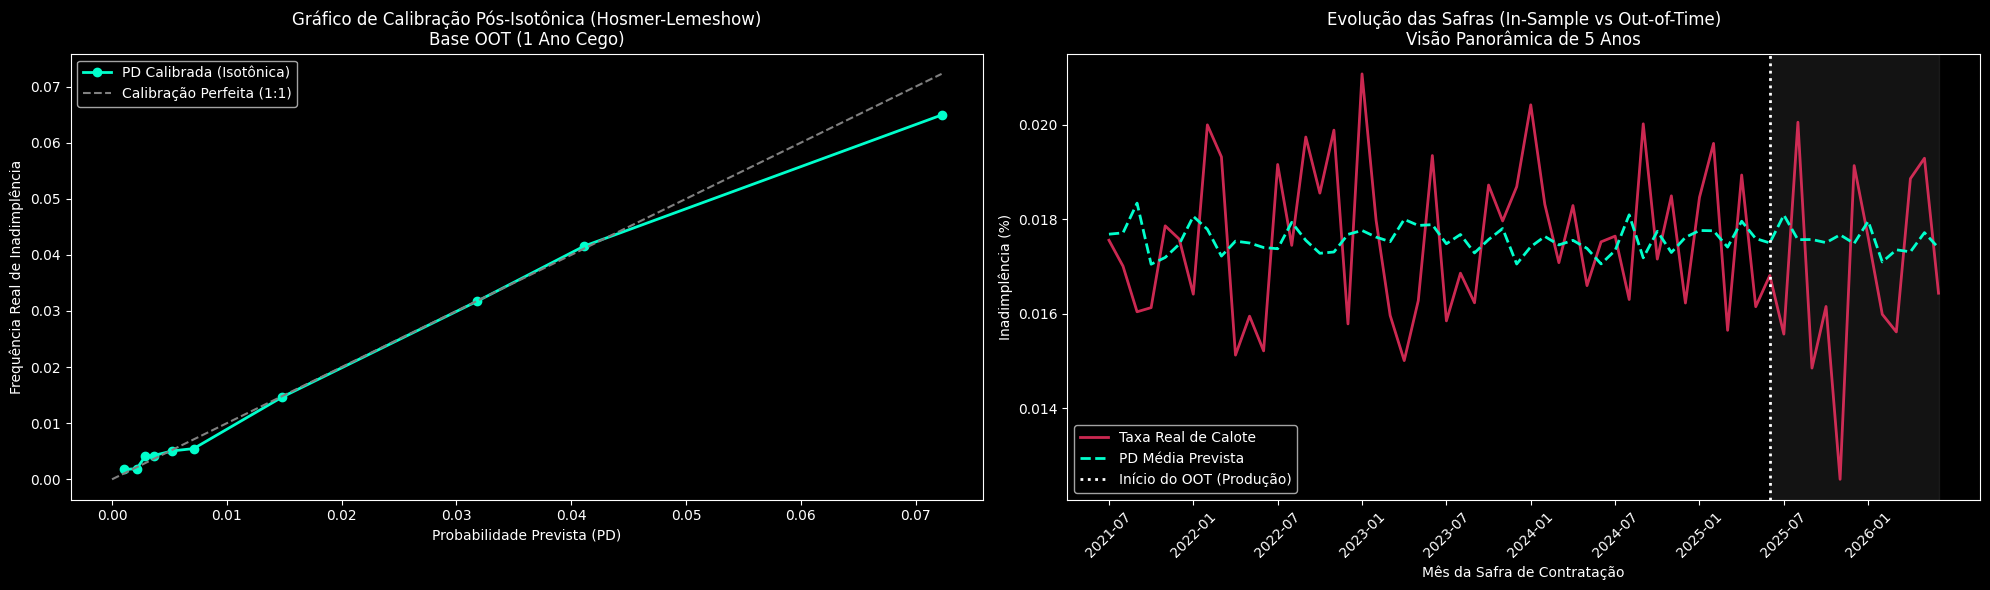

In [26]:
print("\n--- 3. PAINEL VINTAGE: BACKTESTING DE 60 MESES ---")

# Agrupando a base inteira (df) por mês de safra
backtest_full = df.groupby('mes_safra').agg(
    Taxa_Real=('default_flag', 'mean'),
    PD_Calibrada=('pd_calibrada', 'mean')
).reset_index()
backtest_full['mes_safra_str'] = backtest_full['mes_safra'].astype(str)

# Gráfico 2: Backtesting 5 Anos
ax2.plot(backtest_full['mes_safra_str'], backtest_full['Taxa_Real'], color='#ff3366', linewidth=2, label='Taxa Real de Calote', alpha=0.8)
ax2.plot(backtest_full['mes_safra_str'], backtest_full['PD_Calibrada'], color='#00ffcc', linestyle='--', linewidth=2, label='PD Média Prevista')

# A linha mágica que separa o Treino da Produção Simulada
mes_corte = data_corte_producao.strftime('%Y-%m')
if mes_corte in backtest_full['mes_safra_str'].values:
    idx_corte = backtest_full[backtest_full['mes_safra_str'] == mes_corte].index[0]
    ax2.axvline(x=idx_corte, color='white', linestyle=':', linewidth=2, label='Início do OOT (Produção)')
    
    # Sombreando a área de OOT para destaque
    ax2.axvspan(idx_corte, len(backtest_full)-1, color='gray', alpha=0.15)

ax2.set_title("Evolução das Safras (In-Sample vs Out-of-Time)\nVisão Panorâmica de 5 Anos")
ax2.set_xlabel("Mês da Safra de Contratação")
ax2.set_ylabel("Inadimplência (%)")

# Para não poluir o eixo X com 60 datas, mostramos a cada 6 meses
xticks_idx = np.arange(0, len(backtest_full), 6)
ax2.set_xticks(xticks_idx)
ax2.set_xticklabels(backtest_full['mes_safra_str'].iloc[xticks_idx], rotation=45)

ax2.legend()
plt.tight_layout()
plt.show()